In [66]:
# basic plotting imports
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import h5py
import time
import numpy as np
import pandas as pd

from neurodsp import spectral
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from scipy.stats import f_oneway
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.preprocessing import OneHotEncoder
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score, KFold

from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup

from tqdm.notebook import tqdm

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})

import warnings
warnings.filterwarnings('ignore')

In [67]:
# Function to train the model with progress tracking
def train_model_with_progress(X_train, y_train, max_iter=100, regression_type = 'Ridge'):
    if regression_type == 'Ridge':
        model = Ridge(solver='saga', max_iter=max_iter, random_state=42)
        progress_bar = tqdm(range(max_iter), desc="Training Ridge Regression")
        for _ in progress_bar:
            model.max_iter += 1
            model.fit(X_train, y_train)
    elif regression_type == 'lasso':

        # Initialize Lasso Model
 
        model = Lasso(alpha=0.1, max_iter=max_iter, warm_start=True, random_state=42)  # warm_start=True allows continuation of training
        
        # Progress bar for training
        progress_bar = tqdm(range(max_iter), desc="Training Lasso Regression")
        for _ in progress_bar:
            model.max_iter += 1  # Incrementally increase the number of iterations
            model.fit(X_train, y_train)  # Fit model
            
                

    return model

#### Data source

These data are the [PVC-6 data from CRCNS](https://crcns.org/data-sets/vc/pvc-6/about_pvc-6). From their summary:

>The data sets consist of whole cell current clamp slice electrophysiology recordings made from single neurons from coronal sections of the visual cortex of adult male mice. The experiments were performed in the presence of blockers of fast synaptic transmission with the goal of understanding the diversity of intrinsic neuronal excitability between cell classes. These experiments represent preliminary datasets being used to refine methods working towards producing slice electrophysiology data at scale.

These data are ideal for several reasons. First, and most critical for us, is that they're sampled at 200,000 Hz! So if we want to parameterize individual action potentials, for a 1ms AP we'll have 200 data points. This is much more approachable than the 20-40 datapoints that have been limiting us on the other datsets.

Second, these are intracellular patch clamp recordings, so they're not susceptible to our concern that extracellular AP shapes are affected by the position of the electrode relative to the neuron, which is not necessaily stable over time (meaning that any observed AP shape differences could theoretically be driven by movement rather than physiology).

Finally, these neurons were driven by 1/f pink noise, which we like a lot. The variability of the 1/f exponent over time will allow us to link stimulus parameters to any variation in AP shape parameters.

In [68]:
# open and load the data

fs = 200000 # sampling rate
one_ms = int(fs / 1000)

total_sweeps = 66

# 153098_04_02_data has 0 through 66 sweeps
# 151145_04_Data  has 0 through 91 sweeps
filename = '/Users/blancamartin/Downloads/153098.04.02_data.h5' # filename

# open file
f = h5py.File(filename, 'r')

# list(f.keys())

# qc_data = f['qcSweep_Key']
# qc_data[0, :, :]

In [69]:
# helper functions

# load sweeps
def load_sweep(sweep_number):
    # load sweep
    dset = f['Sweep_' + str(sweep_number)]

    # create array of time indices
    convert_to_ms = (fs / 1000)
    times = np.arange(0, np.shape(dset)[0]) / convert_to_ms # in ms instead of sec

    return dset, times

# get the power spectrum of the stimulus
def get_stim_spectrum(dset, fs, nperseg, all_data=True):
    
    if all_data == True:
        stim_data = dset[:, 0]
        fxx, pxx = spectral.compute_spectrum(stim_data, fs, method='welch',
                    window='hann', nperseg=nperseg)
    
    if all_data == False:
        fxx, pxx = spectral.compute_spectrum(dset, fs, method='welch',
                window='hann', nperseg=nperseg)
        
    return fxx, pxx

# plot the ephys data
def plot_ephys_data(dset, times, index_start, index_end):
    plot_range = (index_start, index_end)
    plt.plot(times[plot_range[0]:plot_range[1]],
        dset[plot_range[0]:plot_range[1], 1], '.')

# plot the stimulus
def plot_stim_data(dset, times, index_start, index_end):
    plot_range = (index_start, index_end)
    plt.plot(times[plot_range[0]:plot_range[1]],
        dset[plot_range[0]:plot_range[1], 0], '.')

# plot the stimulus spectrum
def plot_stim_spectrum(fxx, pxx, xlim, ylim):
    plt.loglog(fxx, pxx)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power (V^2/Hz)')
    plt.xlim(xlim)
    plt.ylim(ylim)

# find the spike times
def find_spike_times(data, thresh_mv, thresh_ms):
    # thresh_mv is the voltage threshold that needs to be crossed
    # thresh_ms is how many ms each peak needs to be from the next

    peaks = find_peaks(data, height=thresh_mv, distance=thresh_ms)
    idx_spikes = peaks[0] # spike indices
    amp_spikes = peaks[1]['peak_heights'] # spike amplitudes

    return idx_spikes, amp_spikes

# define exponential function
def exp_func(times, exp_amp, exp_lambda, exp_timeshift, exp_const):
    return exp_amp * np.exp(-exp_lambda * (times - exp_timeshift)) + exp_const

# fit exponential data
def fit_exp_nonlinear(times, data, initial_guesses, bounds):
    popt, _ = curve_fit(exp_func, times, data, p0=initial_guesses, bounds=bounds,  maxfev=10000)
    exp_amp, exp_lambda, exp_timeshift, exp_const = popt
    return exp_amp, exp_lambda, exp_timeshift, exp_const

#### Constant current

Some of the sweeps are driven by a constant current, as can be seen below. For now we'll ignore these, but in theory, depending on the stimulus parameters, these could be used to measure any AP shape parameter adaptation over time, as well as a control to compare against 1/f pink noise stimulation.

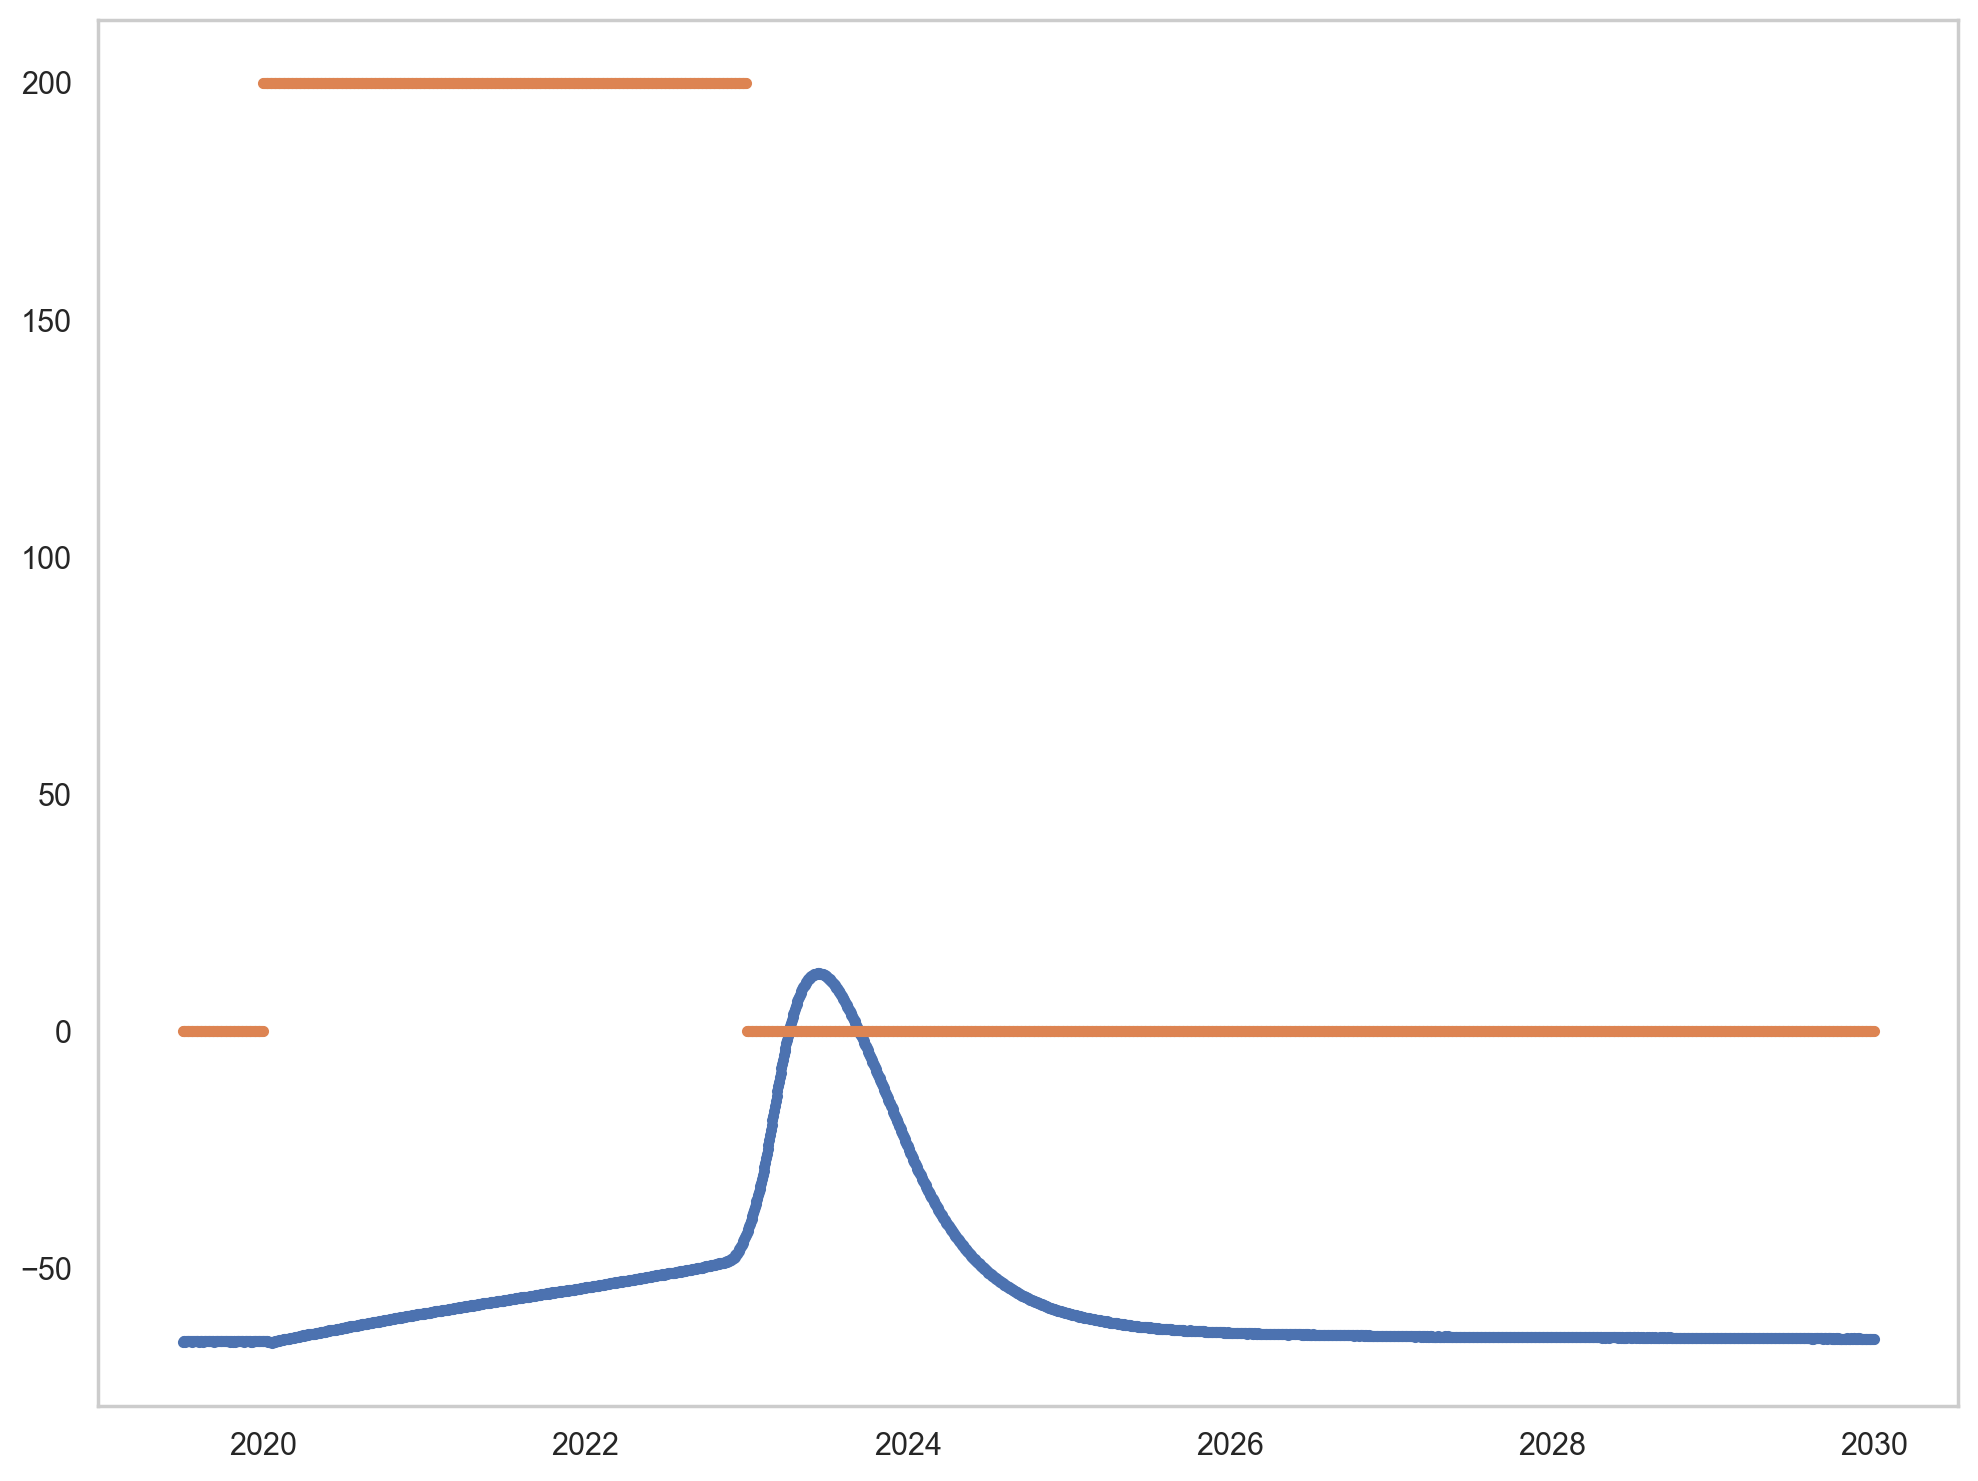

In [70]:
sweep_number = 3
index_start = 403900
index_end = 406000

dset, times = load_sweep(sweep_number)
plot_ephys_data(dset, times, index_start, index_end)
plot_stim_data(dset, times, index_start, index_end)
plt.show()

#### Pink noise (1/f) stimulation

Many of the sweeps are drive by pink noise, and we can leverage the variability in this stimulus to examine the link between variations in the stimulus and AP shape parameters.

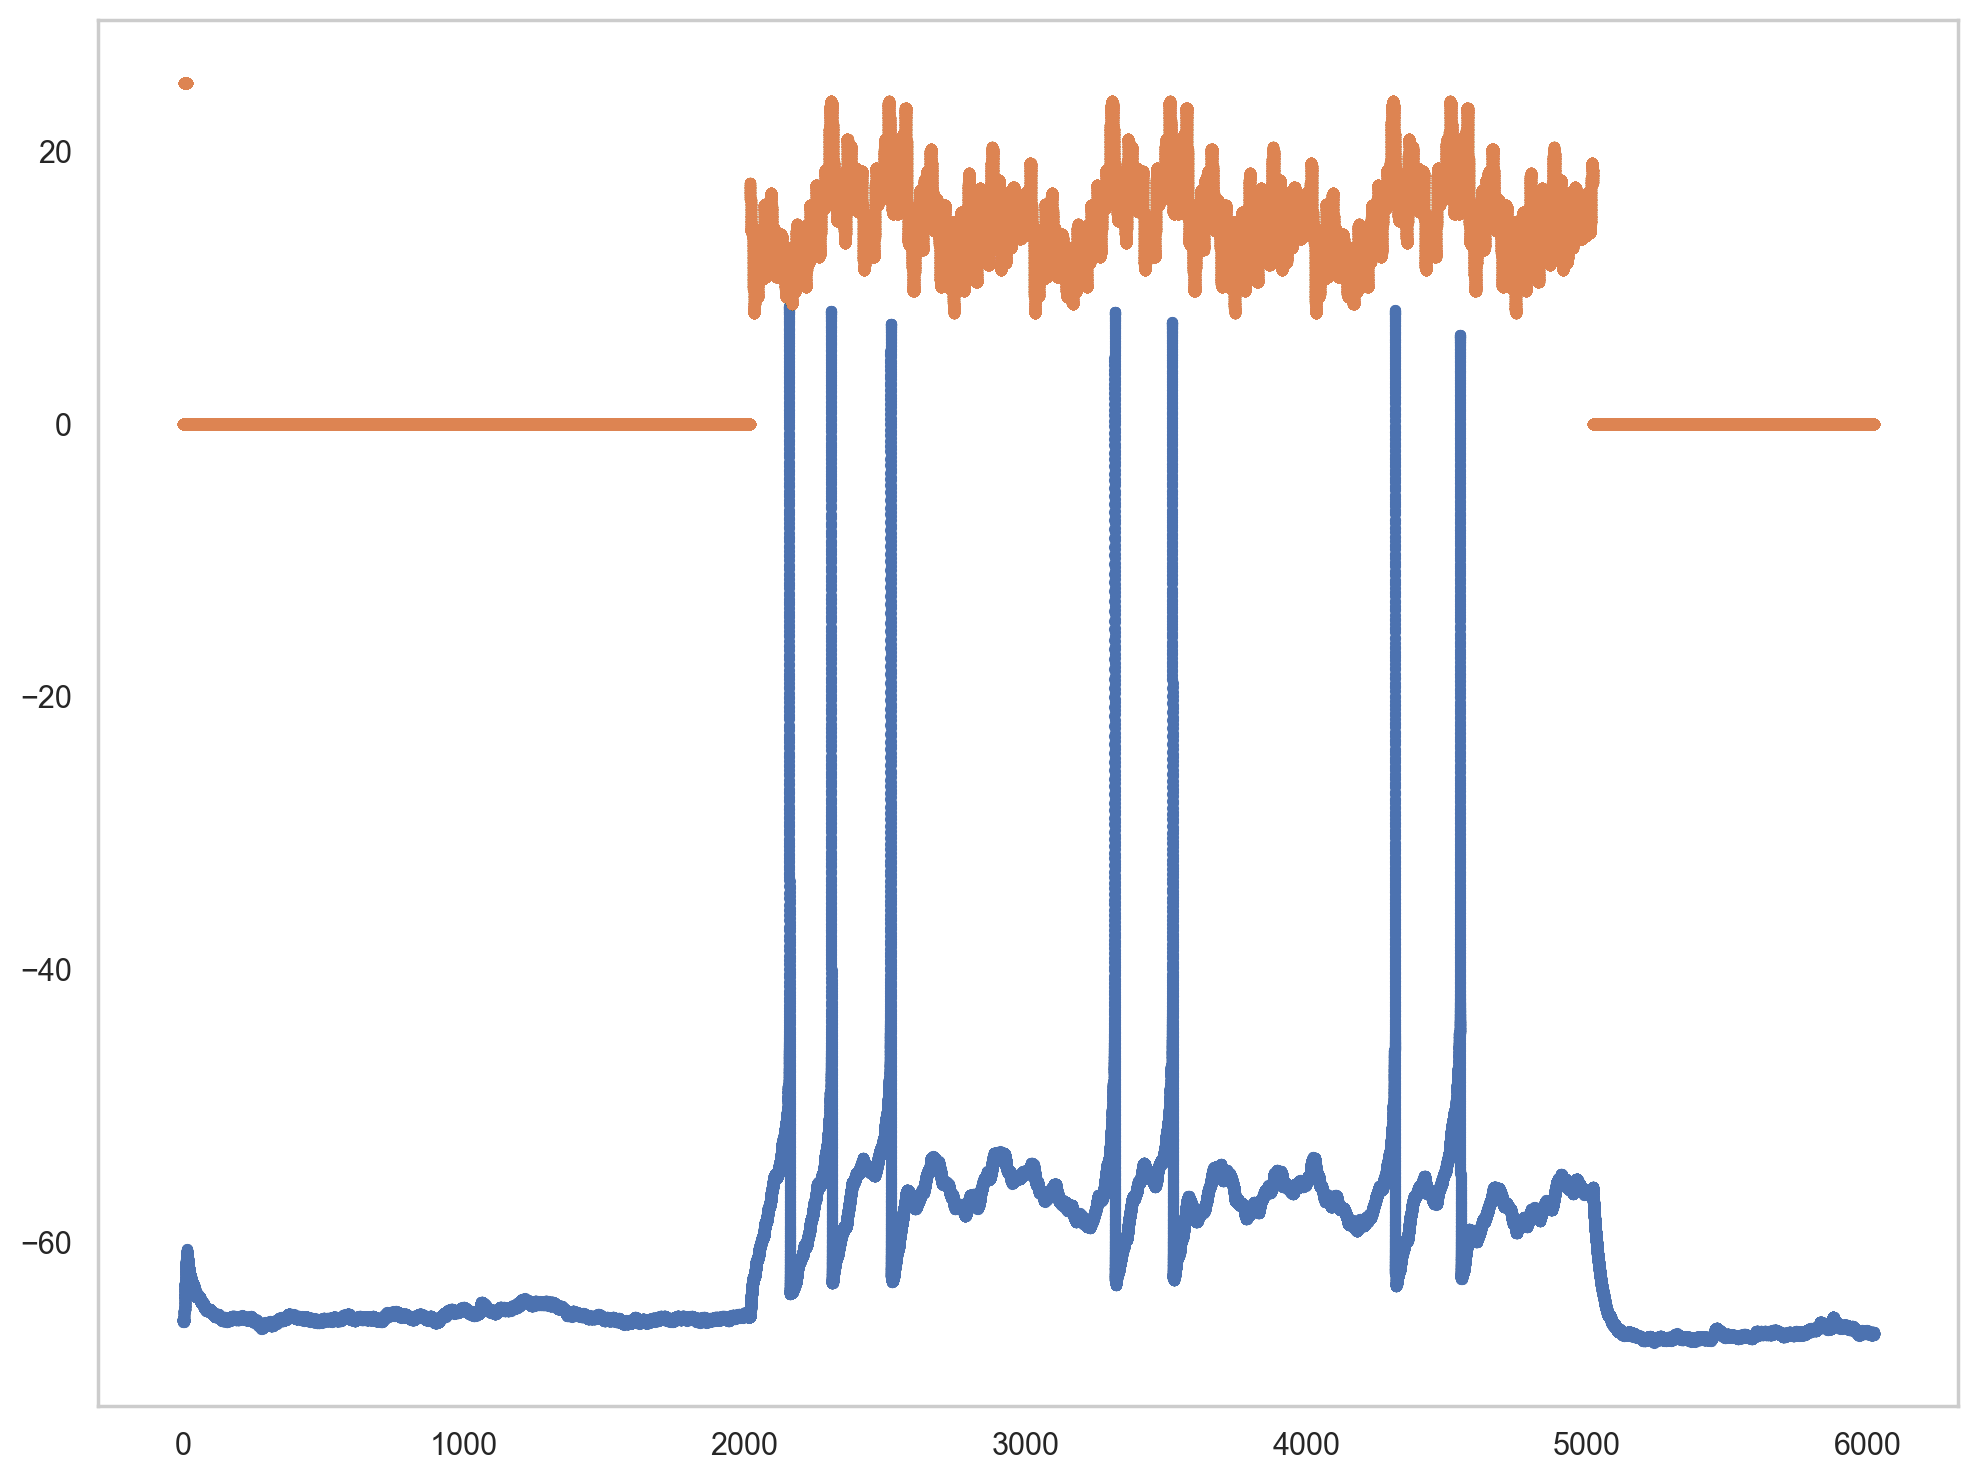

In [71]:
sweep_number = 14
index_start = 0
index_end = int(10e10)

dset, times = load_sweep(sweep_number)
plot_ephys_data(dset, times, index_start, index_end)
plot_stim_data(dset, times, index_start, index_end)
plt.show()

#### Pink noise stimulus spectrum

You can see below that the stimulus is only 1/f in the range of ~[10, 200], so for future 1/f paramterization, we'll fit a linear regression to the loglog spectrum on that range, if the time windows are sufficient. - the analysis here was running specparam on the data not the stimulus :0 

### Do all the pink noise info gathering here

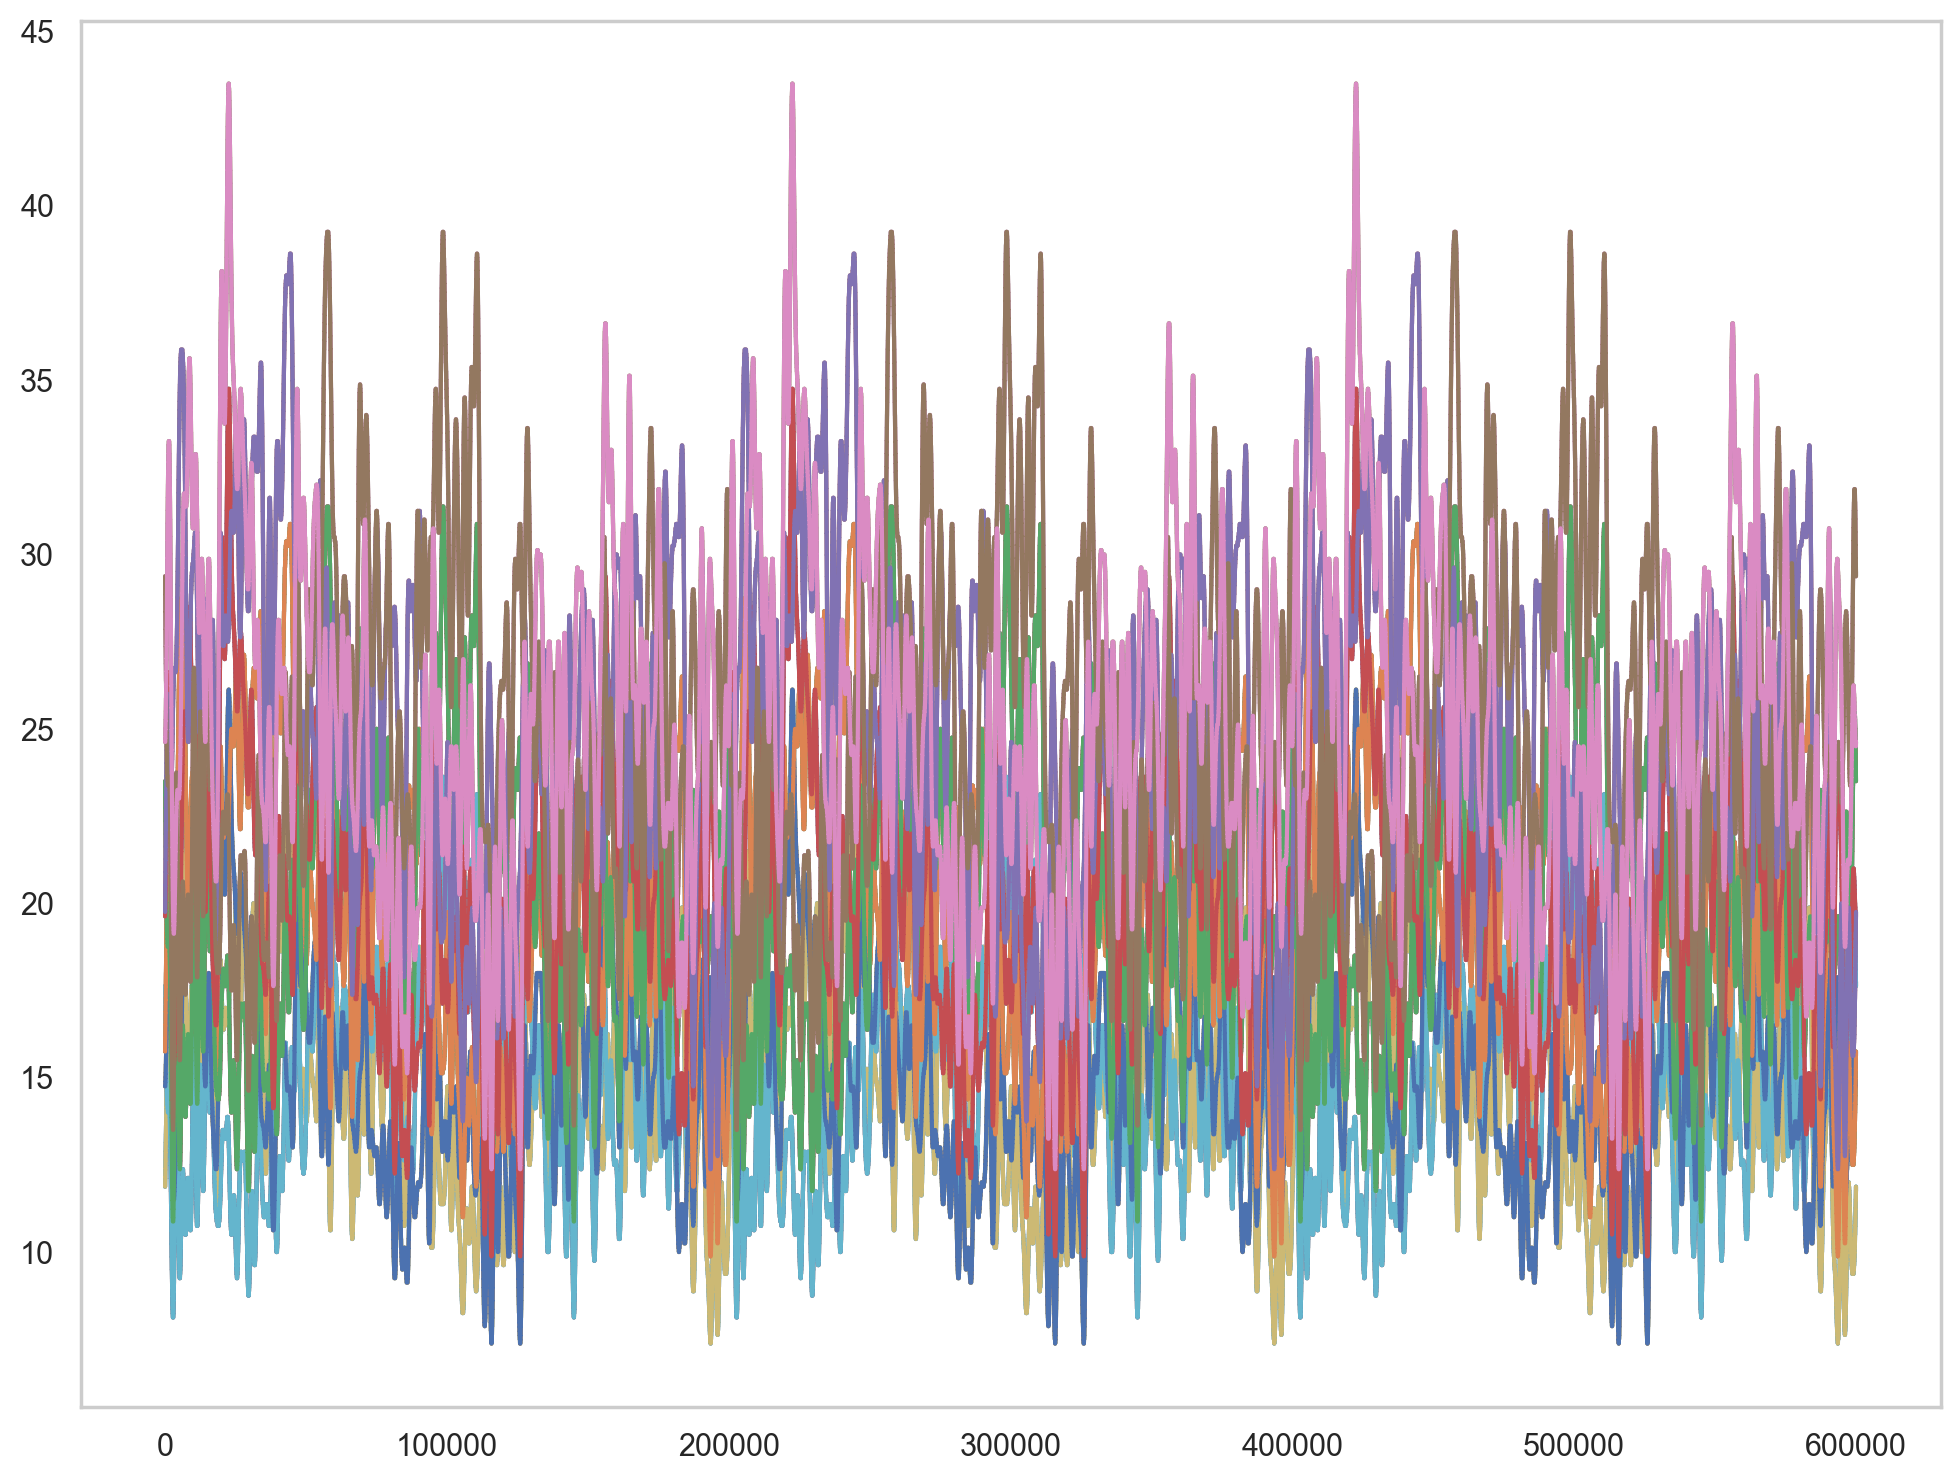

In [72]:
#generate dict with info of pink noise variations
all_pink_noise = {}
pink_type_num = 0
#pink_stim_dict = {}
pink_types = []



# 0 through 66 sweeps
for i_sweeps in range(66):


    #load data
    dset, times = load_sweep(i_sweeps)

    stim_data = dset[:, 0] # current injection
    

    # set the first 25 ms to zero to get rid of mini-pulse at beginning
    stim_data[0:5000] = 0
    stim_data = stim_data[stim_data!=0]
    
 

    if np.size(stim_data) > 2:
        # a pearson correlation between current and time is
            # nan for constant, near 1.0 for ramp, and low for pink noise
        r, _ = pearsonr(np.arange(np.size(stim_data)), stim_data)
        

        # check stim type
        if (np.isnan(r)):
            stim_type = 'constant'
            pink_type = 'constant'
        elif (~np.isnan(r) & (r>0.95)):
            stim_type = 'ramp'
            pink_type = 'ramp'
        elif (~np.isnan(r) & (r<0.95)):
            stim_type = 'pink'
            plt.plot(stim_data)
          
    else:
        stim_type = 'none'
        pink_type = 'none'


    if stim_type == 'pink':
        
        #get specific variation of pink noise 
        if r  not in all_pink_noise:
            pink_type_num = pink_type_num + 1
            pink_type = 'PinkNoise'+str(pink_type_num)
            all_pink_noise[r] = pink_type
            #get power spec for that pink noise type 
            fxx, pxx = get_stim_spectrum(stim_data, fs, nperseg=fs/4, all_data = False)
            xlim = (10e-2, 10e5)
            ylim = (10e-10, 10e-1)
            #plot_stim_spectrum(fxx, pxx, xlim, ylim)
            #plt.axvline(x=10)
            #plt.axvline(x=200)
            #plt.title(pink_type)
            #plt.show()


        else:
            pink_type = all_pink_noise[r]
            
    pink_types.append(pink_type)
        
        
            
   

       


In [73]:
pink_types

['ramp',
 'ramp',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'none',
 'constant',
 'constant',
 'PinkNoise1',
 'PinkNoise2',
 'PinkNoise3',
 'constant',
 'PinkNoise4',
 'PinkNoise5',
 'PinkNoise6',
 'constant',
 'PinkNoise7',
 'PinkNoise8',
 'PinkNoise9',
 'constant',
 'constant',
 'constant',
 'constant',
 'PinkNoise1',
 'PinkNoise10',
 'PinkNoise3',
 'constant',
 'PinkNoise4',
 'PinkNoise5',
 'PinkNoise6',
 'constant',
 'PinkNoise7',
 'PinkNoise8',
 'PinkNoise9',
 'constant',
 'constant',
 'constant',
 'constant',
 'PinkNoise1',
 'PinkNoise10',
 'PinkNoise3',
 'constant',
 'PinkNoise4',
 'PinkNoise5',
 'PinkNoise6',
 'constant',
 'PinkNoise7',
 'PinkNoise8',
 'PinkNoise9',
 'constant',
 'ramp',
 'ramp',
 'ramp',
 'constant',
 'constant',
 'constant',
 'constant',
 'none',
 'constant',
 'constant',
 'constant']

#### Process the data!

The pink noise sweeps all begin with a brief (sub-threshold, always?) stimulus, and then the pink noise stimulus that evokes APs. I use a simple peak-finding approach to find all APs, and then extract time windows around those APs for parameterization of both the APs and the stimulus.

In order to find the inflection point where the AP "starts", we take the difference (~derivative) of the intracellular data around the spike, and find the point where that derivative rises above the noise. This differenced time series is smoothed using simple lowess smoothing, to make things easier.

One cool thing to note here is how similar to an extracelluar AP this derivative of the intracellular AP looks! This probably isn't a coincidence, and has been remarked upon for a very long time. It's worth considering in our future analyses.

In [74]:
# Plot single spike, and its derivative
i_sweeps = 28
dset, times = load_sweep(i_sweeps, f, fs)

stim = dset[:, 0] # current injection
data = dset[:, 1] # ephys data

#########################
# find spikes
thresh_mv = -10
thresh_ms = one_ms * 1 # 1 ms

idx_spikes, amp_spikes = find_spike_times(data, thresh_mv, thresh_ms)

#########################
i_spikes = 0
    
# get windows around spikes
# create window indices
window_length = (10, 10) # in ms
window_pre = int(one_ms * window_length[0])
window_post = int(one_ms * window_length[1])

# get window
window_spike_pre = (idx_spikes[i_spikes]-window_pre)
window_spike_post = (idx_spikes[i_spikes]+window_post)

# get window for times as well
windowed_times = times[(idx_spikes[i_spikes]-window_pre):
                    (idx_spikes[i_spikes]+window_post)]

# get data window
windowed_data = data[window_spike_pre:window_spike_post]

# difference of data, and smooth it
d_windowed_data = np.diff(windowed_data)
smoothed_data = sm.nonparametric.lowess(d_windowed_data, windowed_times[1:], frac=0.008)

# smoothed data
d_smoothed_times = smoothed_data[:, 0]
d_smoothed_data = smoothed_data[:, 1]

plt.plot(windowed_times, windowed_data, 'b', alpha = 0.8, linewidth = 3., label='intra')
plt.plot(d_smoothed_times, (d_smoothed_data*80)-50, 'k', linewidth = 3., label='differenced')
plt.legend()
plt.show()

TypeError: load_sweep() takes 1 positional argument but 3 were given

### Parameterize complete dataset 

In [ ]:
all_data = []
all_times = []
for i_sweeps in range(66):

    #load data
    dset, times = load_sweep(i_sweeps)

    
    data = dset[:, 1] # ephys data
    all_times.append(times)
    all_data.append(data)

In [ ]:

df_sweep = []
df_stim_type = []
df_spike_number = []
df_voltage_ramp = []
df_inflection_time = []
df_inflection_mv = []
df_peak_amplitude = []
df_peak_sharpness = []
df_decay_lambda = []
df_decay_const = []
# df_spike_width = []
df_stim_exp = []
df_stim_mean = []
df_stim_std = []
df_pinktype = []

all_contant_spks = []
all_ramp_spks = []
all_pink_spks = []

# 0 through 66 sweeps
for i_sweeps in range(66):

    #load data
    dset, times = load_sweep(i_sweeps)

    stim = dset[:, 0] # current injection
    data = dset[:, 1] # ephys data

    #########################
    # find spikes
    thresh_mv = -10
    thresh_ms = one_ms * 1 # 1 ms

    idx_spikes, amp_spikes = find_spike_times(data, thresh_mv, thresh_ms)

    #########################
    # loop across spikes
    if np.size(idx_spikes) > 0:

        #########################
        # check if sweep stim is constant, ramp, or pink

        stim_data = dset[:, 0]

        # set the first 25 ms to zero to get rid of mini-pulse at beginning
        stim_data[0:5000] = 0
        stim_data = stim_data[stim_data!=0]

        if np.size(stim_data) > 2:
            # a pearson correlation between current and time is
                # nan for constant, near 1.0 for ramp, and low for pink noise
            r, _ = pearsonr(np.arange(np.size(stim_data)), stim_data)

            # check stim type
            if (np.isnan(r)):
                stim_type = 'constant'
            elif (~np.isnan(r) & (r>0.95)):
                stim_type = 'ramp'
            elif (~np.isnan(r) & (r<0.95)):
                stim_type = 'pink'
        else:
            stim_type = 'none'

        #########################
        # paramterize each spike
        for i_spikes in range(np.size(idx_spikes)):
            # get windows around spikes
            # create window indices
            window_length = (10, 10) # in ms
            window_pre = int(one_ms * window_length[0])
            window_post = int(one_ms * window_length[1])

            # get window
            window_spike_pre = (idx_spikes[i_spikes]-window_pre)
            window_spike_post = (idx_spikes[i_spikes]+window_post)

            # get window for times as well
            windowed_times = times[(idx_spikes[i_spikes]-window_pre):
                                (idx_spikes[i_spikes]+window_post)]

            # get data window
            windowed_data = data[window_spike_pre:window_spike_post]

            # difference of data, and smooth it
            d_windowed_data = np.diff(windowed_data)
            smoothed_data = sm.nonparametric.lowess(d_windowed_data, windowed_times[1:], frac=0.008)

            # smoothed data
            d_smoothed_times = smoothed_data[:, 0]
            d_smoothed_data = smoothed_data[:, 1]

            if stim_type == 'constant':
                all_contant_spks.append(d_smoothed_data )
            elif stim_type == 'ramp':
                all_ramp_spks.append(d_smoothed_data )
            elif stim_type == 'pink':
                all_pink_spks.append(d_smoothed_data )
                 


            #########################
            # inflection_time
            thresh_zscore = 40 # zscore threshold for inflection point
                                # REALLY high, since it's so low noise

            # get mean and std of first ms of data
            noise_window = d_smoothed_data[0:one_ms] 
            noise_mean = np.mean(noise_window)
            noise_std = np.std(noise_window)

            # zscore spike relative to window above
            z_data = (d_smoothed_data-noise_mean) / noise_std

            # find the peak of the zscored data
            idx_z_peak, _ = find_spike_times(z_data, thresh_zscore, thresh_ms)

            # find the peak of the real data
            idx_spike_peak, _ = find_spike_times(windowed_data, thresh_mv, thresh_ms)

            # find inflection voltage and time relative to spike peak
            inflection_time = np.abs(z_data[0:idx_z_peak[0]]-thresh_zscore)
            idx_inflection = np.argmin(inflection_time)

            # get the voltage ramp slope for the 0.5 ms before inflection point
            idx_ramp_start = idx_inflection - int(0.5 * one_ms) # 0.5 ms before
            ramp_times = windowed_times[idx_ramp_start:idx_inflection]

            voltage_ramp, _ = np.polyfit(ramp_times, windowed_data[idx_ramp_start:idx_inflection], 1)

            inflection_time = idx_spike_peak - idx_inflection
            inflection_time = inflection_time[0] / one_ms

            inflection_mv = windowed_data[idx_inflection]


            #########################
            # peak voltage
            idx_spike_peak, amp_spike_peak = find_spike_times(windowed_data, thresh_mv, thresh_ms)
            mv_peak = amp_spike_peak[0]


            #########################
            # peak sharpness
                # this is just Scott's simple oscillation sharpness approach
            sharpness_peak = ((windowed_data[idx_spike_peak[0]]-windowed_data[idx_spike_peak[0]-5]) + 
            (windowed_data[idx_spike_peak[0]]-windowed_data[idx_spike_peak[0]+5])) / 2


            #########################
            # voltage decay rate and voltage floor
            decay_curve_shift = one_ms/2 # the ap peak is curved, so shift to the right to get a cleaner decay
            decay_curve_floor_time = one_ms*5 # decide when to call it the floor
            idx_spike_peak, amp_peak = find_spike_times(windowed_data, thresh_mv, thresh_ms)
            exp_window = idx_spike_peak[0]+int(decay_curve_shift) # shift to the right
            exp_window_end = exp_window+int(decay_curve_floor_time) # when to end the curve
            exp_data = windowed_data[exp_window:exp_window_end]
            exp_times = windowed_times[exp_window:exp_window_end]

            # initial guesses, derived from physiological estimating
            initial_guesses = np.array([50, 1, windowed_times[exp_window], -60], dtype=np.float64)
            bounds = ([0, 0, 0, -100], [1000, 3, 10e9, 50]) # set some reasonable bounds

            # fit the dang thing
            exp_amp, exp_lambda, exp_timeshift, exp_const = \
                fit_exp_nonlinear(exp_times, exp_data, initial_guesses, bounds)

            # # check the fit
            # fitted_model = exp_func(exp_times, exp_amp, exp_lambda, exp_timeshift, exp_const)

            # # plot it!
            # plt.plot(exp_times, exp_data, 'k')
            # plt.plot(exp_times, fitted_model, 'b')
            # plt.show()


            if stim_type == 'pink':
                #########################
                # quantify stimulus parameters

                # create window indices
                window_length = (10, 10) # in ms
                window_pre = int(one_ms * window_length[0])
                window_post = int(one_ms * window_length[1])
                
                # get the 5 ms before the inflection point
                inflection_pre_window = int(idx_inflection - (one_ms * 5))

                # get window
                window_spike_pre = (idx_spikes[i_spikes]-window_pre)
                window_spike_post = (idx_spikes[i_spikes]+window_post)

                windowed_stim = stim[window_spike_pre:window_spike_post]
                windowed_stim = windowed_stim[inflection_pre_window:idx_inflection]

                # get slope of spectrum (exponent)
                fxx, pxx = spectral.compute_spectrum(windowed_stim, fs, method='welch',
                                window='hann', nperseg=np.size(windowed_stim))

                # get rid of zero Hz
                fxx = fxx[1:]
                pxx = pxx[1:]

                stim_exp, _ = np.polyfit(np.log10(fxx), np.log10(pxx), 1)
                stim_exp = -stim_exp # change from slope to exponent

                # stim mean and std
                stim_mean = np.mean(windowed_stim)
                stim_std = np.std(windowed_stim)
            
            else: # not pink noise, so set stim params to nan
                stim_exp = np.nan
                stim_mean = np.nan
                stim_std = np.nan


            #########################
            # collect all the relevant features
            df_sweep.append(i_sweeps)
            df_stim_type.append(stim_type)
            df_spike_number.append(i_spikes)
            df_voltage_ramp.append(voltage_ramp)
            df_inflection_time.append(inflection_time)
            df_inflection_mv.append(inflection_mv)
            df_peak_amplitude.append(mv_peak)
            df_peak_sharpness.append(sharpness_peak)
            df_decay_lambda.append(exp_lambda)
            df_decay_const.append(exp_const)
            # df_spike_width.append(spike_width)
            df_stim_exp.append(stim_exp)
            df_stim_mean.append(stim_mean)
            df_stim_std.append(stim_std)
            df_pinktype.append(pink_types[i_sweeps])


In [ ]:
#try collapsing the all data array to 1d (concatenate all sweeps)
all_data_flat =  [n for one_dim in all_data for n in one_dim]

In [ ]:
plt.plot(all_data_flat)


In [ ]:

#recreate parameterization using the Spike class
#Run spikeparam on real EAPs |
sp = Spike(thresh_amp= -10, window_length=(5., 5.), smooth_frac=.008, pre_inflection_ms = 0.5)


sp.fit(all_data_flat, fs, n_jobs=-1, progress=tqdm)

In [ ]:
sp.plot(show_points=True)

In [ ]:
sp.df_features

In [ ]:
sp.filter_features()

In [ ]:
df_features = sp.df_features

#### Combine sp class dataframe with other info 

In [ ]:
# create df
    # stim_type = 'constant', 'ramp', 'pink'
df = pd.DataFrame({'sweep': df_sweep, 'stim_type': df_stim_type, 'spike_num': df_spike_number,
                     'stim_exp': df_stim_exp, 'stim_mean': df_stim_mean,
                    'stim_std': df_stim_std,'pink_type':df_pinktype },
        columns=['sweep', 'stim_type', 'spike_num', 'stim_exp', 'stim_mean', 'stim_std', 'pink_type'])


In [ ]:
df = pd.concat([df, df_features], axis=1)


In [ ]:
pink_test = df.loc[df['stim_type'] == 'pink']

In [ ]:
# Group by 'sweep' and use `tail(1)` to get the last entry of each group
last_spikes_indices = df.groupby('sweep').tail(1).index

# last_spikes_indices now contains the indices of the last spikes in each sweep
print("Indices of last spikes in each sweep:", last_spikes_indices)

In [ ]:

#replace infs with NaN
df_all = df.drop(['sweep', 'stim_type', 'pink_type', 'spike_num'], axis=1)

pd.plotting.scatter_matrix(df_all, alpha=0.5)
plt.show()

spikes_corr = df_all.corr()
# plot the heatmap and annotation on it
sns.heatmap(spikes_corr, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)
plt.show()

rho = df_all.corr()
pval = df_all.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [ ]:
df_pink = df.loc[df['stim_type'] == 'pink']
df_pink = df_pink.drop(['sweep', 'stim_type', 'pink_type', 'spike_num'], axis=1)

pd.plotting.scatter_matrix(df_pink, alpha=0.5)
plt.show()

spikes_corr = df_pink.corr()
# plot the heatmap and annotation on it
sns.heatmap(spikes_corr, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)
plt.show()

rho = df_pink.corr()
pval = df_pink.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

### Get first spikes with pink noise

#### Only look at first spike to minimize adaptations etc. effects

In [ ]:
df_pink_first = df.loc[df['stim_type'] == 'pink']
df_pink_first = df_pink_first.loc[df['spike_num'] == 0]
df_pink_first = df_pink_first.drop(['sweep', 'stim_type', 'spike_num', 'pink_type',], axis=1)

pd.plotting.scatter_matrix(df_pink_first, alpha=0.5)
plt.show()

spikes_corr = df_pink_first.corr()
# plot the heatmap and annotation on it
sns.heatmap(spikes_corr, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)
plt.show()

rho =df_pink_first.corr()
pval = df_pink_first.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

### ISI prediction using other spike features 

#### On all spikes

In [ ]:
plt.hist(df_pink['log_isi'])

### Remove last spike in each sweep for ISI predictor - 
the ISIs are weird cause they are pointing to a spike in a different sweep

In [ ]:
# Find which indices are actually present in df_pink
valid_indices = [idx for idx in last_spikes_indices if idx in df_pink.index]

# Drop the last spikes
df_pink_filtered = df_pink.drop(valid_indices)

In [ ]:
#get dfs for regression models 

df_pink_no_stim_filtered = df_pink_filtered.drop(['stim_exp', 'stim_mean', 'stim_std' ], axis=1)
df_pink_no_stim_first = df_pink_first.drop(['stim_exp', 'stim_mean', 'stim_std' ], axis=1)
df_pink_onlystim_filtered = df_pink_filtered.drop(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width','peak_sharpness', 'exp_lambda', 'exp_const' ], axis=1)
df_pink_onlystim_first = df_pink_first.drop(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width','peak_sharpness', 'exp_lambda', 'exp_const' ], axis=1)


### Replicate brad's plots for all pink spikes 

In [ ]:
# Create a figure with 3 subplots side by side
fig, axs = plt.subplots(1, 3, figsize=(19, 6))  # Adjust the size as needed

# First plot: exp_lambda vs stim_mean
axs[0].plot(df_pink_filtered['exp_const'], df_pink_filtered['stim_mean'], '.C6', markersize=20)  # Blue dots

axs[0].set_xlabel('Decay exp constant', fontsize=30)
axs[0].set_ylabel('Stim mean', fontsize=30)
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

axs[0].tick_params(axis='both', labelsize=20)


# First plot: exp_lambda vs stim_mean
axs[1].plot(df_pink_filtered['peak_sharpness'], df_pink_filtered['stim_mean'], '.C5', markersize=20)  # Blue dots

axs[1].set_xlabel('Peak sharpness', fontsize=30)
axs[1].set_ylabel('Stim mean', fontsize=30)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].tick_params(axis='both', labelsize=20)
             
# Third plot: stim_mean vs log_isi
axs[2].plot(df_pink_filtered['stim_mean'], df_pink_filtered['log_isi'], '.C7', markersize=20) 

axs[2].set_xlabel('Log isi', fontsize=30)
axs[2].set_ylabel('Stim mean', fontsize=30)
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].tick_params(axis='both', labelsize=20)






# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

### Plot only pinks spikes for fig 2 panel

In [ ]:
pink_spikes = df[df['stim_type'] == 'pink']

# Get the indices to plot
indices_to_plot = pink_spikes.index.tolist()

In [ ]:
sp.plot(indices_to_plot, color='hotpink', mode = 'full', show_points=True)


# After plotting, get the current figure and axis
fig = plt.gcf()  # Get the current figure
ax = plt.gca()   # Get the current axis

# Modify the font size of the labels
ax.set_xlabel('Time (ms)', fontsize=18)
ax.set_ylabel('Voltage', fontsize=18)

# Modify the font size of the legend
legend = ax.get_legend()
if legend:
    plt.setp(legend.get_texts(), fontsize=18)
# Modify the font size of the tick numbers
ax.tick_params(axis='both', which='major', labelsize=16)  # Adjust tick label size for both axes


# Modify line thickness
for line in ax.get_lines():
    line.set_linewidth(3)

# Finally, re-display the updated plot
plt.show()

### Stim mean predictor from all features - RIDGE REGRESSION

In [ ]:
all_rsqs = []
all_rsqs_cv = []
# Iterate over each stimulus feature
for stim_feature in ['stim_exp', 'stim_mean', 'stim_std']:


    # Define a range of random states
    random_states = [2, 3, 10, 20,42, 48, 64, 80,100,110,128, 256]
    
    # List to store results
    rsqs = []
    rsqs_cv = []
    for randoms in random_states:

        # Filter data for the current stimulus feature
        data = df_pink_filtered.dropna(subset=[stim_feature])
        
        # Define features (X) and target variable (y)
        X = data.drop(columns=['stim_exp', 'stim_mean', 'stim_std'])
        y = data[stim_feature]
        
        # Split data into train and test sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=randoms)
        
        # Train linear regression model
        model = Ridge()
      
        model.fit(X_train, y_train)
        
        # Evaluate model
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rsquared = model.score(X_test, y_test)
        
        print(f"Stimulus Feature: {stim_feature}")
        print(f"Mean Squared Error: {mse}")
        print(f"R-squared: {rsquared}")
        print()

        rsqs.append(rsquared )

        #ALSO DO CROSS VALIDATION
        # Define a k-fold cross-validation strategy
        kf = KFold(n_splits=5, shuffle=True, random_state=randoms)
        
        # Train linear regression model using k-fold CV to collect MSE or R-squared across folds
        scores = cross_val_score(Ridge(), X, y, cv=kf, scoring='r2')
        
        # Print the results
        print(f"Cross-validated R-squared scores: {scores}")
        print(f"Average R-squared: {scores.mean():.3f} ± {scores.std():.3f}")
        rsqs_cv.append(scores)
    

# Visualize results
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred, s =55)
    plt.xlabel('Actual stim mean', fontsize=20)
    plt.ylabel('Predicted stim mean', fontsize=20)
    plt.title(f'Scatter Plot of Actual vs. Predicted Values for {stim_feature}')
    plt.xticks(fontsize=16)               
    plt.yticks(fontsize=16) 
    
    # Plot regression line
    m, b = np.polyfit(y_test, y_pred, 1)
    plt.plot(y_test, m * y_test + b, color='red', linewidth=2)
    
    plt.show()



 # Get the coefficients of the linear regression model
    coefficients = model.coef_
    
    # Get the names of the features
    feature_names = X.columns
    
    # Create a DataFrame to display feature names and their corresponding coefficients
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
    
    # Sort the DataFrame by coefficient values to see the most important features
    feature_importance_df = feature_importance_df.sort_values(by='Coefficient', ascending=False)

    
    
    
    # Define color mapping
    color_mapping = {
        'peak_amp': 'C5', # Example colors
        'exp_const': 'C6',
        'exp_lambda': 'C6',
        'inflection_amp': 'C3',
        'ramp_amp': 'C4',
        'inflection_time': 'C3',
        'peak_sharpness': 'C5',
        'peak_width': 'C5',
        'log_isi': 'C7'
        
}

    # Apply color mapping
    feature_importance_df['Color'] = feature_importance_df['Feature'].map(color_mapping)
    print(feature_importance_df)
    
    
    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df, palette=feature_importance_df['Color'])
    plt.title('Feature Importance')
    plt.xlabel('Importance', fontsize=20)
    plt.ylabel('Feature', fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.show()



    all_rsqs.append(rsqs)
    all_rsqs_cv.append(rsqs_cv)


In [ ]:
average_rsq_stim_mean_cv = np.mean(all_rsqs_cv[1])
std_rsq_stim_mean_cv = np.std(all_rsqs_cv[1])

print("average rsq stim mean linear regression model cv: ", str(average_rsq_stim_mean_cv))
print("std rsq stim mean linear regression model cv: ", str(std_rsq_stim_mean_cv))

In [ ]:
average_rsq_stim_mean_cv = np.mean(all_rsqs_cv[0])
std_rsq_stim_mean_cv = np.std(all_rsqs_cv[0])

print("average rsq stim mean linear regression model cv: ", str(average_rsq_stim_mean_cv))
print("std rsq stim mean linear regression model cv: ", str(std_rsq_stim_mean_cv))

In [ ]:
average_rsq_stim_mean_cv = np.mean(all_rsqs_cv[2])
std_rsq_stim_mean_cv = np.std(all_rsqs_cv[2])

print("average rsq stim mean linear regression model cv: ", str(average_rsq_stim_mean_cv))
print("std rsq stim mean linear regression model cv: ", str(std_rsq_stim_mean_cv))

### Predict log isi - 3 DIFFERENT RIDGE REGRESSION MODELS BASED ON FEATURE COMBINATIONS 

In [ ]:
#### Only features

In [ ]:



# Define a range of random states
random_states = [2, 3, 10, 48, 64, 80,100,110,128, 256, 300,400]

# List to store results
rsqs = []
rsqs_cv = []
for randoms in random_states:

    # Filter data for the current stimulus feature
    data = df_pink_filtered.dropna(subset=[stim_feature])
    
    # Define features (X) and target variable (y)
    X = data.drop(columns=['stim_exp', 'stim_mean', 'stim_std', 'log_isi'])
    y = data['log_isi']
    
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=randoms)
    
    # Train linear regression model
    model = Ridge()
  
    model.fit(X_train, y_train)
    
    # Evaluate model
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rsquared = model.score(X_test, y_test)
    
    print(f"Stimulus Feature: {stim_feature}")
    print(f"Mean Squared Error: {mse}")
    print(f"R-squared: {rsquared}")
    print()

    rsqs.append(rsquared )

    #ALSO DO CROSS VALIDATION
    # Define a k-fold cross-validation strategy
    kf = KFold(n_splits=5, shuffle=True, random_state=randoms)
    
    # Train linear regression model using k-fold CV to collect MSE or R-squared across folds
    scores = cross_val_score(Ridge(), X, y, cv=kf, scoring='r2')
    
    # Print the results
    print(f"Cross-validated R-squared scores: {scores}")
    print(f"Average R-squared: {scores.mean():.3f} ± {scores.std():.3f}")
    rsqs_cv.append(scores)


# Visualize results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, s =55)
plt.xlabel('Actual log_isi mean', fontsize=20)
plt.ylabel('Predicted log_isi mean', fontsize=20)
plt.title(f'Scatter Plot of Actual vs. Predicted Values for {stim_feature}')
plt.xticks(fontsize=16)               
plt.yticks(fontsize=16) 

# Plot regression line
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m * y_test + b, color='red', linewidth=2)

plt.show()

all_features_y_test = y_test
all_features_y_pred = y_pred

# Get the coefficients of the linear regression model
coefficients = model.coef_

# Get the names of the features
feature_names = X.columns

# Create a DataFrame to display feature names and their corresponding coefficients
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort the DataFrame by coefficient values to see the most important features
feature_importance_df = feature_importance_df.sort_values(by='Coefficient', ascending=False)




# Define color mapping
color_mapping = {
    'peak_amp': 'C5', # Example colors
    'exp_const': 'C6',
    'exp_lambda': 'C6',
    'inflection_amp': 'C3',
    'ramp_amp': 'C4',
    'inflection_time': 'C3',
    'peak_sharpness': 'C5',
    'peak_width': 'C5',
    'log_isi': 'C7'
    
}

# Apply color mapping
feature_importance_df['Color'] = feature_importance_df['Feature'].map(color_mapping)
print(feature_importance_df)


# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df, palette=feature_importance_df['Color'])
plt.title('Feature Importance')
plt.xlabel('Importance', fontsize=20)
plt.ylabel('Feature', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

all_features_feature_importance_df = feature_importance_df



In [ ]:
average_rsq_stim_mean_cv = np.mean(rsqs_cv)
std_rsq_stim_mean_cv = np.std(rsqs_cv)

print("average rsq stim mean linear regression model cv: ", str(average_rsq_stim_mean_cv))
print("std rsq stim mean linear regression model cv: ", str(std_rsq_stim_mean_cv))

r2 = average_rsq_stim_mean_cv
n = len(X) # number of observations 
p = len(X.columns) # number of predictors/features
# Calculate the adjusted R-squared
adjusted_r_squared = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("adjsuted rsq stim mean linear regression model cv: ", str(adjusted_r_squared))

#### Features and stim mean

In [ ]:


# Define a range of random states
random_states = [2, 3, 10,  48, 64, 80,100,110,128, 256, 300, 400]

# List to store results
rsqs_isi = []
rsqs_cv_isi = []
for randoms in random_states:

    # Filter data for the current stimulus feature
    data = df_pink_filtered.dropna(subset=[stim_feature])
    
    # Define features (X) and target variable (y)
    X = data.drop(columns=[ 'log_isi'])
    y = data['log_isi']
    
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=randoms)
    
    # Train linear regression model
    model = Ridge()
  
    model.fit(X_train, y_train)
    
    # Evaluate model
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rsquared = model.score(X_test, y_test)
    
   

    rsqs.append(rsquared )

    #ALSO DO CROSS VALIDATION
    # Define a k-fold cross-validation strategy
    kf = KFold(n_splits=5, shuffle=True, random_state=randoms)
    
    # Train linear regression model using k-fold CV to collect MSE or R-squared across folds
    scores = cross_val_score(Ridge(), X, y, cv=kf, scoring='r2')
    
    # Print the results
    print(f"Cross-validated R-squared scores: {scores}")
    print(f"Average R-squared: {scores.mean():.3f} ± {scores.std():.3f}")
    rsqs_cv.append(scores)


# Visualize results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, s =55)
plt.xlabel('Actual log_isi mean', fontsize=20)
plt.ylabel('Predicted log_isi mean', fontsize=20)
plt.title(f'Scatter Plot of Actual vs. Predicted Values for {stim_feature}')
plt.xticks(fontsize=16)               
plt.yticks(fontsize=16) 

# Plot regression line
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m * y_test + b, color='red', linewidth=2)

plt.show()


all_features_and_stim_y_test = y_test

all_features_and_stim_y_pred = y_pred


# Get the coefficients of the linear regression model
coefficients = model.coef_

# Get the names of the features
feature_names = X.columns

# Create a DataFrame to display feature names and their corresponding coefficients
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort the DataFrame by coefficient values to see the most important features
feature_importance_df = feature_importance_df.sort_values(by='Coefficient', ascending=False)




# Define color mapping
color_mapping = {
    'peak_amp': 'C5', # Example colors
    'exp_const': 'C6',
    'exp_lambda': 'C6',
    'inflection_amp': 'C3',
    'ramp_amp': 'C4',
    'inflection_time': 'C3',
    'peak_sharpness': 'C5',
    'peak_width': 'C5',
    'stim_mean': 'hotpink',
    'stim_std': 'hotpink',
    'stim_exp': 'hotpink'
    
}

# Apply color mapping
feature_importance_df['Color'] = feature_importance_df['Feature'].map(color_mapping)



# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df, palette=feature_importance_df['Color'])
plt.title('Feature Importance')
plt.xlabel('Importance', fontsize=20)
plt.ylabel('Feature', fontsize=20)
plt.xlim(-0.20, 0.20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

all_features_and_stim_feature_importance_df = feature_importance_df


In [ ]:
average_rsq_stim_mean_cv = np.mean(rsqs_cv)
std_rsq_stim_mean_cv = np.std(rsqs_cv)

print("average rsq stim mean linear regression model cv: ", str(average_rsq_stim_mean_cv))
print("std rsq stim mean linear regression model cv: ", str(std_rsq_stim_mean_cv))

r2 = average_rsq_stim_mean_cv
n = len(X) # number of observations 
p = len(X.columns) # number of predictors/features
# Calculate the adjusted R-squared
adjusted_r_squared = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("adjsuted rsq stim mean linear regression model cv: ", str(adjusted_r_squared))

#### Only pink stim mean 

In [ ]:

# Define a range of random states
random_states = [2, 3, 10, 48, 64, 80,100,110,128, 256, 300, 400]

# List to store results
rsqs_isi = []
rsqs_cv_isi = []
for randoms in random_states:

    # Filter data for the current stimulus feature
    data = df_pink_filtered.dropna(subset=[stim_feature])
    
    # Define features (X) and target variable (y)
    X = data.drop(columns=[ 'inflection_time', 'log_isi', 'exp_lambda', 'inflection_amp', 'peak_amp', 'ramp_amp', 'exp_const', 'peak_sharpness', 'peak_width'])
    y = data['log_isi']
    
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=randoms)
    
    # Train linear regression model
    model = Ridge()
  
    model.fit(X_train, y_train)
    
    # Evaluate model
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rsquared = model.score(X_test, y_test)
    
    print(f"Stimulus Feature: {stim_feature}")
    print(f"Mean Squared Error: {mse}")
    print(f"R-squared: {rsquared}")
    print()

    rsqs.append(rsquared )

    #ALSO DO CROSS VALIDATION
    # Define a k-fold cross-validation strategy
    kf = KFold(n_splits=5, shuffle=True, random_state=randoms)
    
    # Train linear regression model using k-fold CV to collect MSE or R-squared across folds
    scores = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')
    
    # Print the results
    print(f"Cross-validated R-squared scores: {scores}")
    print(f"Average R-squared: {scores.mean():.3f} ± {scores.std():.3f}")
    rsqs_cv.append(scores)


# Visualize results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, s =55)
plt.xlabel('Actual log_isi mean', fontsize=20)
plt.ylabel('Predicted log_isi mean', fontsize=20)
plt.title(f'Scatter Plot of Actual vs. Predicted Values for {stim_feature}')
plt.xticks(fontsize=16)               
plt.yticks(fontsize=16) 

# Plot regression line
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m * y_test + b, color='red', linewidth=2)

plt.show()

only_stim_y_test = y_test
only_stim_y_pred = y_pred

# Get the coefficients of the linear regression model
coefficients = model.coef_

# Get the names of the features
feature_names = X.columns

# Create a DataFrame to display feature names and their corresponding coefficients
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort the DataFrame by coefficient values to see the most important features
feature_importance_df = feature_importance_df.sort_values(by='Coefficient', ascending=False)





# Define color mapping
color_mapping = {
    'peak_amp': 'C5', # Example colors
    'exp_const': 'C6',
    'exp_lambda': 'C6',
    'inflection_amp': 'C3',
    'ramp_amp': 'C4',
    'inflection_time': 'C3',
    'peak_sharpness': 'C5',
    'peak_width': 'C5',
    'stim_mean': 'hotpink',
    'stim_std': 'hotpink',
    'stim_exp': 'hotpink'
    
}

# Apply color mapping
feature_importance_df['Color'] = feature_importance_df['Feature'].map(color_mapping)
print(feature_importance_df)


# Plot
plt.figure(figsize=(10, 2))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df, palette=feature_importance_df['Color'])
plt.title('Feature Importance')
plt.xlabel('Importance', fontsize=20)
plt.ylabel('Feature', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(-0.20, 0.20)
plt.show()

only_stim_feature_importance_df = feature_importance_df

In [ ]:
average_rsq_stim_mean_cv = np.mean(rsqs_cv)
std_rsq_stim_mean_cv = np.std(rsqs_cv)

print("average rsq stim mean linear regression model cv: ", str(average_rsq_stim_mean_cv))
print("std rsq stim mean linear regression model cv: ", str(std_rsq_stim_mean_cv))

r2 = average_rsq_stim_mean_cv
n = len(X) # number of observations 
p = len(X.columns) # number of predictors/features
# Calculate the adjusted R-squared
adjusted_r_squared = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("adjsuted rsq stim mean linear regression model cv: ", str(adjusted_r_squared))

### Bar plot with actual vs adjusted rsqs 

In [ ]:


# Names of the models
labels = ['Average r-squared', 'Adjusted r-squared']

# Adjusted R-squared values for each group
no_stim = [0.136, 0.119]  # Adjusted R-squared values for models without stimulation features
with_stim = [0.148, 0.123]  # Adjusted R-squared values for models with stimulation features
only_stim = [0.142, 0.136]

x = np.arange(len(labels))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, no_stim, width, label='No stim features', color='#5b83bc')
rects2 = ax.bar(x, with_stim, width, label='With stim features', color='#974a75')
rects3 = ax.bar(x + width, only_stim, width, label='Only stim features', color='#df8ac1')

# Adding titles and labels

ax.set_ylabel('R-squared', fontsize=20, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=16, fontweight='bold')

# Set the y-ticks to specific values to reduce clutter
ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4])
ax.set_yticklabels(['0', '0.1', '0.2', '0.3', '0.4'], fontsize=14)

# Adding text labels on the bars
def autolabel(rects):
    """Attach a text label above each bar displaying its height, formatted to three decimal places."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=16, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.legend(fontsize=16, frameon=True, facecolor='white', framealpha=1)

# Removing the top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show the plot
plt.ylim(0, 0.2)
plt.show()


### Combined plots for figure - actual vs predicted

In [ ]:

# Create a new figure
plt.figure(figsize=(10, 6))

# First set: all_features (No stim features)
sns.scatterplot(x=all_features_y_test, y=all_features_y_pred, s=55, label='No stim features', color='#5b83bc')
m, b = np.polyfit(all_features_y_test, all_features_y_pred, 1)
plt.plot(all_features_y_test, m * all_features_y_test + b, color='#5b83bc', linewidth=2)

# Second set: all_features_and_stim (With stim features)
sns.scatterplot(x=all_features_and_stim_y_test, y=all_features_and_stim_y_pred, s=55, label='With stim features', color='#974a75')
m, b = np.polyfit(all_features_and_stim_y_test, all_features_and_stim_y_pred, 1)
plt.plot(all_features_and_stim_y_test, m * all_features_and_stim_y_test + b, color='#974a75', linewidth=2)

# Third set: only_stim (Only stim features)
sns.scatterplot(x=only_stim_y_test, y=only_stim_y_pred, s=55, label='Only stim features', color='#df8ac1')
m, b = np.polyfit(only_stim_y_test, only_stim_y_pred, 1)
plt.plot(only_stim_y_test, m * only_stim_y_test + b, color='#df8ac1', linewidth=2)

# Add labels and title
plt.xlabel('Actual log_isi mean', fontsize=20)
plt.ylabel('Predicted log_isi mean', fontsize=20)
plt.title('Combined Scatter Plot of Actual vs. Predicted Values for All Models', fontsize=20)
plt.xticks(fontsize=16)               
plt.yticks(fontsize=16)

# Add legend
plt.legend([], [], frameon=False)

# Show the plot
plt.show()



### Combined plots for figure - feature importance

In [ ]:

# Add a column to each DataFrame to label the model
all_features_feature_importance_df['Model'] = 'No stim features'
all_features_and_stim_feature_importance_df['Model'] = 'With stim features'
only_stim_feature_importance_df['Model'] = 'Only stim features'

# Combine the three DataFrames
combined_feature_importance_df = pd.concat([
    all_features_feature_importance_df,
    all_features_and_stim_feature_importance_df,
    only_stim_feature_importance_df
])

# Plot combined feature importance without the legend
plt.figure(figsize=(12, 8))  # Increase the figure size
sns.barplot(x='Coefficient', y='Feature', hue='Model', data=combined_feature_importance_df, 
            palette=['#5b83bc', '#974a75', '#df8ac1'], linewidth=0.5)  # Increased bar thickness

# Add labels and title
plt.title('Combined Feature Importance for All Models', fontsize=20)
plt.xlabel('Coefficient (Importance)', fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=20)  # Increase font size for the feature names

# Disable the legend
plt.legend([], [], frameon=False)

# Show the plot
plt.show()
